# Этап 3: Анализ предсказаний и Бизнес-логика (Inference)

**Цель:** Проанализировать матрицу ошибок для выявления ограничений модели и разработать пайплайн для решения проблемы отсутствия класса "человек" в исходных данных.

In [ ]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

plt.rcParams['figure.figsize'] = (14, 10)

## 1. Анализ матрицы ошибок

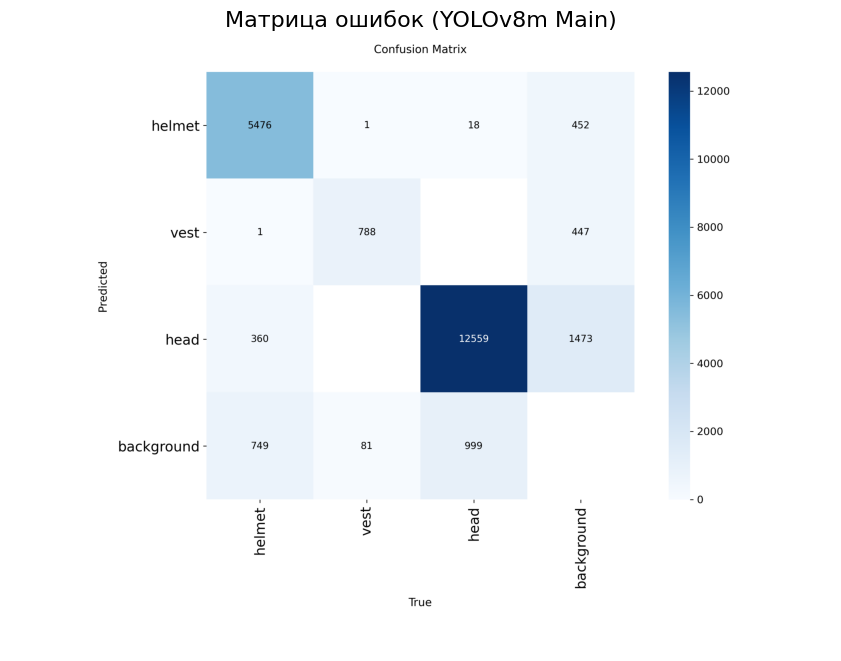

[ВЫВОД] Модель уверенно различает каски и жилеты. Основной источник ошибок (FP) — путаница между классом 'Head' (Голова) и фоном (Background), что вызвано плохим качеством исходных изображений на заднем плане.


In [62]:
cm_path = r"C:\Practicum\results\logs\yolov8m_balanced-3\confusion_matrix.png"

if os.path.exists(cm_path):
    img_cm = Image.open(cm_path)
    plt.imshow(img_cm)
    plt.axis('off')
    plt.title("Матрица ошибок (YOLOv8m Main)", fontsize=16)
    plt.show()
    print("[ВЫВОД] Модель уверенно различает каски и жилеты. Основной источник ошибок (FP) — путаница между классом 'Head' (Голова) и фоном (Background), что вызвано плохим качеством исходных изображений на заднем плане.")

## 2. Разработка бизнес-логики (Каскадный пайплайн)
В ходе EDA (Этап 1) было выявлено, что в разметке датасета отсутствует класс `Person`. Для полноценной работы системы применен подход **Cascade Detection**:
1. Поиск рабочих с помощью предобученной на датасете COCO модели YOLOv8.
2. Поиск СИЗ с помощью нашей обученной модели YOLOv8m.
3. Геометрическое связывание (Intersection) для классификации: `SAFE` (всё надето), `WARNING` (частичное отсутствие), `DANGER` (полное отсутствие).

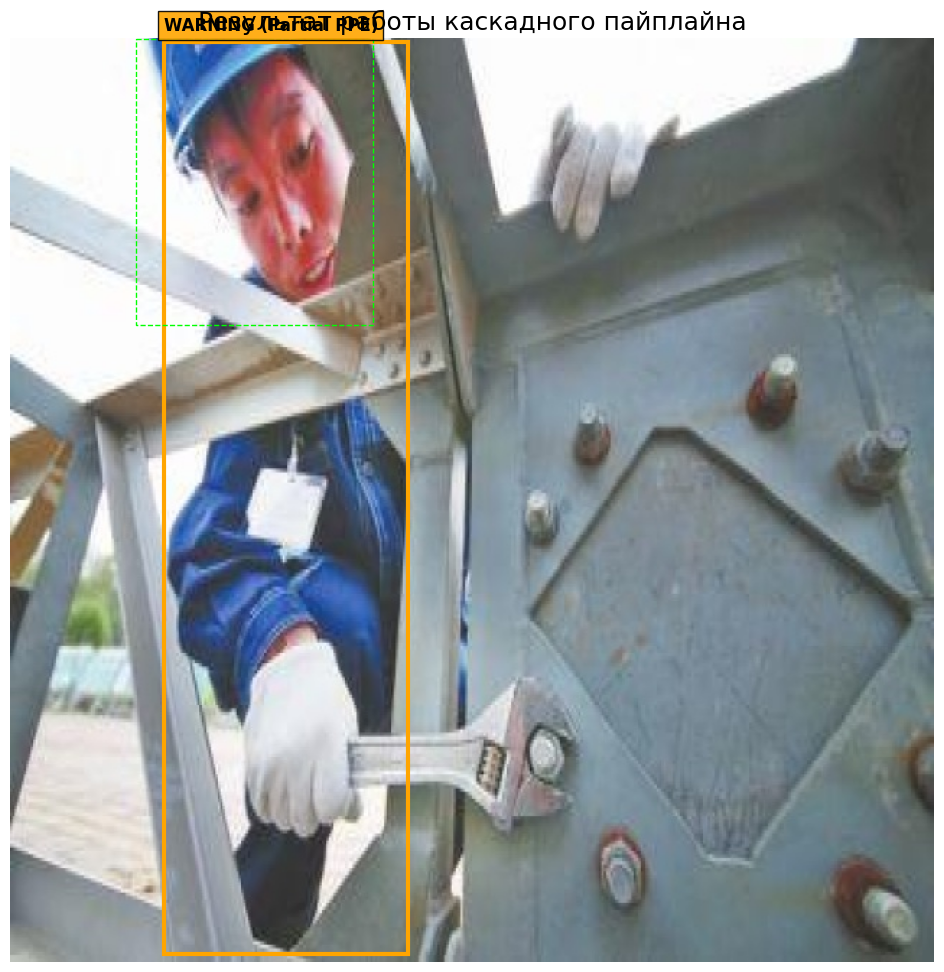

In [96]:
person_model_path = r"C:\Practicum\weights\yolov8m.pt"
person_model = YOLO(person_model_path)

ppe_model_path = r"C:\Practicum\results\logs\yolov8m_balanced-3\weights\best.pt"
ppe_model = YOLO(ppe_model_path)

val_images_dir = r"C:\Practicum\data\processed\images\val"
test_img = random.choice(glob.glob(os.path.join(val_images_dir, "*.jpg")))

img_bgr = cv2.imread(test_img)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

person_results = person_model.predict(test_img, classes=[0], conf=0.25, verbose=False)[0]
ppe_results = ppe_model.predict(test_img, conf=0.5, verbose=False)[0]

fig, ax = plt.subplots(1, figsize=(16, 12))
ax.imshow(img_rgb)

persons = person_results.boxes.data.tolist()
ppes = ppe_results.boxes.data.tolist()

for p_box in persons:
    px1, py1, px2, py2, p_conf, p_cls = p_box
    has_helmet, has_vest = False, False

    for e_box in ppes:
        ex1, ey1, ex2, ey2, e_conf, e_cls = e_box
        cx, cy = (ex1 + ex2) / 2, (ey1 + ey2) / 2

        if px1 <= cx <= px2 and py1 <= cy <= py2:
            if int(e_cls) == 0: has_helmet = True
            if int(e_cls) == 1: has_vest = True

    if has_helmet and has_vest:
        color, text = 'lime', "SAFE (Full PPE)"
    elif has_helmet or has_vest:
        color, text = 'orange', "WARNING (Partial PPE)"
    else:
        color, text = 'red', "DANGER (No PPE)"

    rect = patches.Rectangle((px1, py1), px2-px1, py2-py1, linewidth=3, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(px1, py1-8, text, color='black', fontsize=12, fontweight='bold', bbox=dict(facecolor=color, alpha=0.9))

ppe_colors = {0: "lime", 1: "cyan", 2: "red"}
for e_box in ppes:
    ex1, ey1, ex2, ey2, e_conf, e_cls = e_box
    c = ppe_colors.get(int(e_cls), "white")
    rect = patches.Rectangle((ex1, ey1), ex2-ex1, ey2-ey1, linewidth=1, edgecolor=c, facecolor='none', linestyle='--')
    ax.add_patch(rect)

plt.axis('off')
plt.title("Результат работы каскадного пайплайна", fontsize=18)
plt.show()